In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose

import os

os.makedirs("../visualizations", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/superstore_cleaned.csv")

df.head()

,Order_ID,Invoice_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Region,State,Category,Sub_Category,Product_Name,Quantity,Discount,Sales,Profit
0,ORD-10000,INV-50000,2024-04-12,2024-04-13,Second Class,CUST-1075,Customer 0227,Home Office,South,Virginia,Furniture,Chairs,Desk Lamp,6,0.15,1376.680,195.36
1,ORD-10001,INV-50001,2025-03-11,2025-03-15,Standard Class,CUST-1236,Customer 0042,Consumer,East,New Jersey,Technology,Copiers,Monitor,3,0.00,789.880,153.36
2,ORD-10002,INV-50002,2024-09-27,2024-09-30,First Class,CUST-1197,Customer 0134,Home Office,West,Arizona,Office Supplies,Envelopes,Labels,6,0.05,332.730,59.73
3,ORD-10003,INV-50003,2024-04-16,2024-04-20,Second Class,CUST-1009,Customer 0005,Home Office,West,Colorado,Office Supplies,Paper,Labels,1,0.00,107.800,14.52
4,ORD-10004,INV-50004,2024-03-12,2024-03-15,First Class,CUST-1291,Customer 0026,Home Office,East,New York,Technology,Accessories,Printer,5,0.00,3074.035,366.03


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1000
Columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Invoice_ID     1000 non-null   object 
 2   Order_Date     1000 non-null   object 
 3   Ship_Date      1000 non-null   object 
 4   Ship_Mode      1000 non-null   object 
 5   Customer_ID    1000 non-null   object 
 6   Customer_Name  1000 non-null   object 
 7   Segment        1000 non-null   object 
 8   Region         1000 non-null   object 
 9   State          1000 non-null   object 
 10  Category       1000 non-null   object 
 11  Sub_Category   1000 non-null   object 
 12  Product_Name   1000 non-null   object 
 13  Quantity       1000 non-null   int64  
 14  Discount       1000 non-null   float64
 15  Sales          1000 non-null   float64
 16  Profit         1000 non-null   float64
dtypes: float64(3), int64(1), objec

In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Order_ID         0
Invoice_ID       0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Region           0
State            0
Category         0
Sub_Category     0
Product_Name     0
Quantity         0
Discount         0
Sales            0
Profit           0
dtype: int64


In [5]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print(df["Order_Date"].min())
print(df["Order_Date"].max())

2024-01-01 00:00:00
2025-12-30 00:00:00


In [6]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

numeric_df = df[numeric_columns]

numeric_df.describe()

,Sales,Quantity,Discount,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,911.874720,4.003000,0.089700,108.366690
std,961.715963,2.044791,0.077749,119.324926
min,5.600000,1.000000,0.000000,-56.040000
25%,204.260000,2.000000,0.000000,20.067500
50%,460.025000,4.000000,0.100000,58.685000
75%,1352.170000,6.000000,0.150000,158.452500
max,3074.035000,7.000000,0.300000,366.030000


In [7]:
mean_values = numeric_df.mean()

print("Mean:")
print(mean_values)

Mean:
Sales       911.87472
Quantity      4.00300
Discount      0.08970
Profit      108.36669
dtype: float64


In [8]:
median_values = numeric_df.median()

print("Median:")
print(median_values)

Median:
Sales       460.025
Quantity      4.000
Discount      0.100
Profit       58.685
dtype: float64


In [9]:
std_values = numeric_df.std()

print("Standard Deviation:")
print(std_values)

Standard Deviation:
Sales       961.715963
Quantity      2.044791
Discount      0.077749
Profit      119.324926
dtype: float64


In [10]:
skewness_values = numeric_df.skew()

print("Skewness:")
print(skewness_values)

Skewness:
Sales       1.181999
Quantity    0.003685
Discount    0.790566
Profit      1.200614
dtype: float64


In [11]:
descriptive_statistics = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Mode": numeric_df.mode().iloc[0],
    "Standard Deviation": numeric_df.std(),
    "Skewness": numeric_df.skew()
})

descriptive_statistics

,Mean,Median,Mode,Standard Deviation,Skewness
Sales,911.87472,460.025,3074.035,961.715963,1.181999
Quantity,4.00300,4.000,7.000,2.044791,0.003685
Discount,0.08970,0.100,0.100,0.077749,0.790566
Profit,108.36669,58.685,366.030,119.324926,1.200614


PART 2 — HYPOTHESIS TESTING

In [12]:
segment_values = df["Segment"].dropna().unique()

print("Segments:", segment_values)

Segments: ['Home Office' 'Consumer' 'Corporate']


In [13]:
group1 = df[df["Segment"] == segment_values[0]]["Sales"]
group2 = df[df["Segment"] == segment_values[1]]["Sales"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

print("T-Test")
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Statistically significant difference between the two groups.")
else:
    print("Result: No statistically significant difference between the two groups.")

T-Test
T-statistic: -1.592377722543797
P-value: 0.11175917936234216
Result: No statistically significant difference between the two groups.


In [14]:
contingency_table = pd.crosstab(
    df["Category"],
    df["Region"]
)

print("Contingency Table:")
print(contingency_table)

Contingency Table:
Region           Central  East  South  West
Category                                   
Furniture             72    75     72    66
Office Supplies      132   118    110   100
Technology            63    64     53    75


In [15]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test")
print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Result: There is a significant relationship between Category and Region.")
else:
    print("Result: No significant relationship between Category and Region.")

Chi-Square Test
Chi-square statistic: 6.729588785477883
P-value: 0.34658017707082706
Degrees of freedom: 6
Result: No significant relationship between Category and Region.


In [16]:
sales = df["Sales"].dropna()

mean_sales = sales.mean()
std_error = stats.sem(sales)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(sales) - 1,
    loc=mean_sales,
    scale=std_error
)

print("Mean Sales:", mean_sales)
print("95% Confidence Interval:", confidence_interval)

Mean Sales: 911.87472
95% Confidence Interval: (np.float64(852.195738225311), np.float64(971.5537017746891))


In [17]:
print("STATISTICAL FINDINGS")
print("--------------------")

print(f"Mean Sales: {mean_sales:.2f}")
print(f"Median Sales: {sales.median():.2f}")
print(f"Sales Standard Deviation: {sales.std():.2f}")
print(f"Sales Skewness: {sales.skew():.2f}")

print("\n95% Confidence Interval for Mean Sales:")
print(confidence_interval)

print("\nBUSINESS IMPLICATIONS")
print("---------------------")

if sales.skew() > 0:
    print("Sales distribution is positively skewed, indicating that some orders have much higher sales values.")
elif sales.skew() < 0:
    print("Sales distribution is negatively skewed.")
else:
    print("Sales distribution is approximately symmetric.")

if p_value < 0.05:
    print("The statistical test indicates a significant relationship/difference.")
else:
    print("The statistical test does not indicate a statistically significant relationship/difference.")

STATISTICAL FINDINGS
--------------------
Mean Sales: 911.87
Median Sales: 460.02
Sales Standard Deviation: 961.72
Sales Skewness: 1.18

95% Confidence Interval for Mean Sales:
(np.float64(852.195738225311), np.float64(971.5537017746891))

BUSINESS IMPLICATIONS
---------------------
Sales distribution is positively skewed, indicating that some orders have much higher sales values.
The statistical test does not indicate a statistically significant relationship/difference.


PART 3 — TIME SERIES ANALYSIS

In [18]:
time_series_df = df[["Order_Date", "Sales"]].copy()

time_series_df = time_series_df.set_index("Order_Date")

time_series_df.head()

,Sales
Order_Date,
2024-04-12,1376.680
2025-03-11,789.880
2024-09-27,332.730
2024-04-16,107.800
2024-03-12,3074.035


In [19]:
daily_sales = time_series_df["Sales"].resample("D").sum()

print("Daily Sales:")
print(daily_sales.head())

Daily Sales:
Order_Date
2024-01-01    4774.780
2024-01-02    3555.225
2024-01-03    3074.035
2024-01-04    2062.040
2024-01-05     983.500
Freq: D, Name: Sales, dtype: float64


In [20]:
weekly_sales = time_series_df["Sales"].resample("W").sum()

print("Weekly Sales:")
print(weekly_sales.head())

Weekly Sales:
Order_Date
2024-01-07    18124.560
2024-01-14     9233.140
2024-01-21     7903.995
2024-01-28    16152.825
2024-02-04     8904.305
Freq: W-SUN, Name: Sales, dtype: float64


In [21]:
monthly_sales = time_series_df["Sales"].resample("ME").sum()

print("Monthly Sales:")
print(monthly_sales.head())

Monthly Sales:
Order_Date
2024-01-31    52241.800
2024-02-29    39064.620
2024-03-31    27776.810
2024-04-30    44876.420
2024-05-31    35819.555
Freq: ME, Name: Sales, dtype: float64


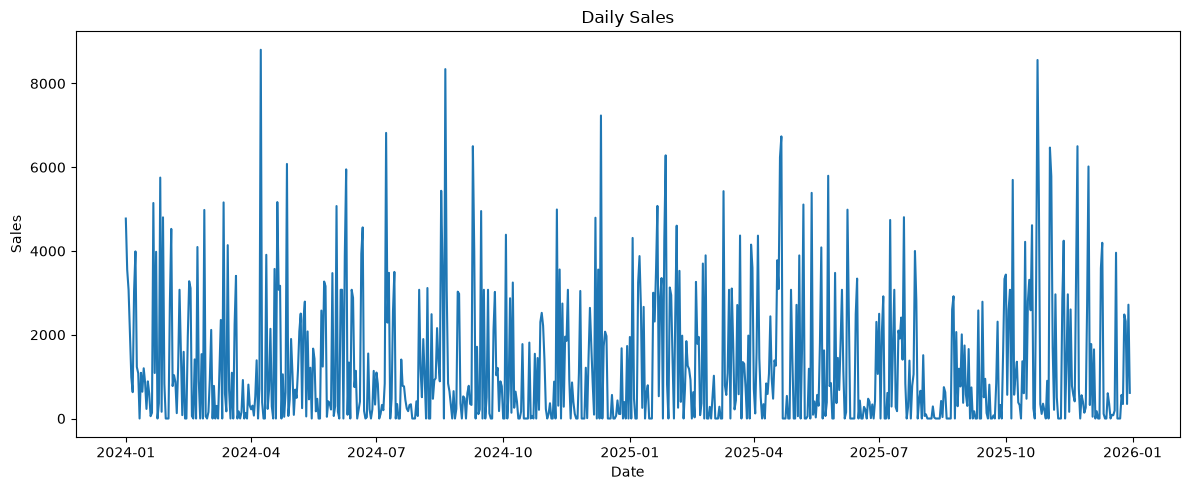

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(daily_sales)

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../visualizations/daily_sales.png")

plt.show()

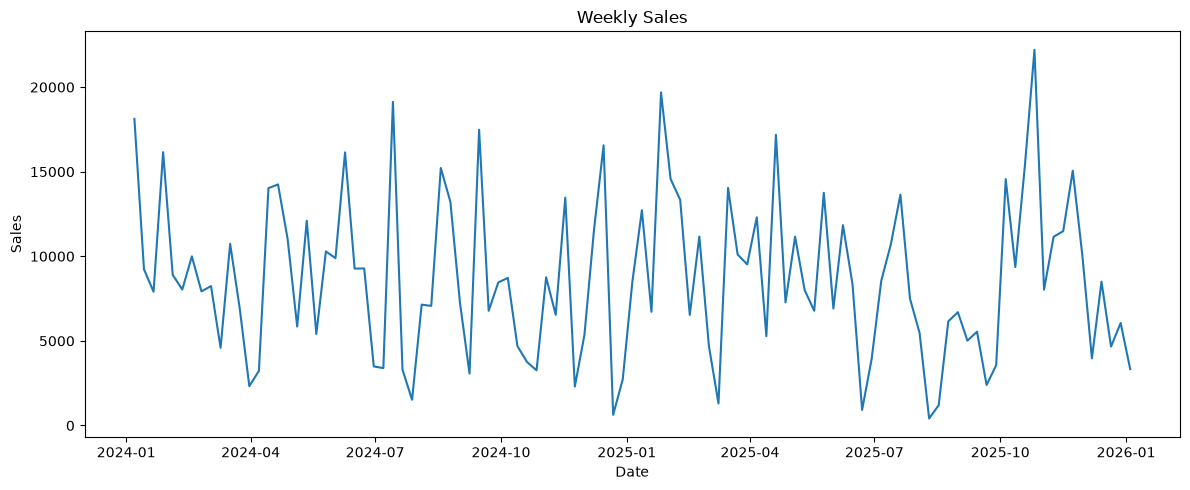

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(weekly_sales)

plt.title("Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../visualizations/weekly_sales.png")

plt.show()

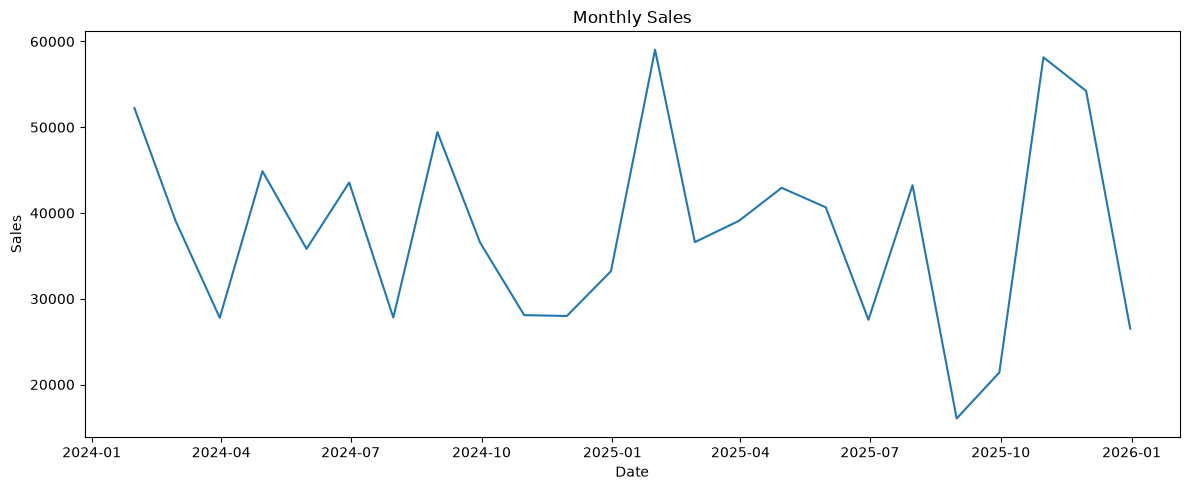

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales)

plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../visualizations/monthly_sales.png")

plt.show()

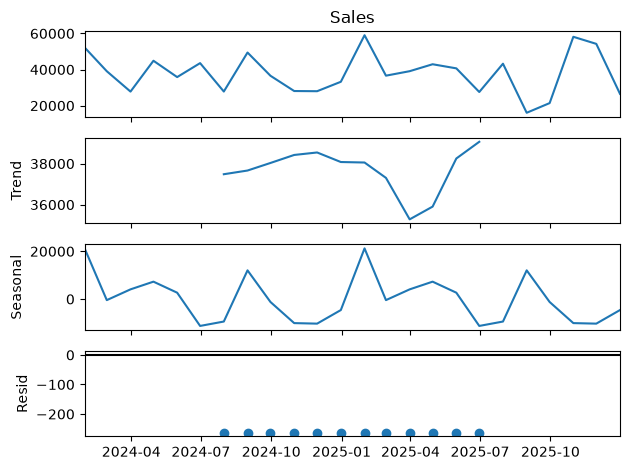

In [25]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

decomposition.plot()

plt.tight_layout()

plt.savefig("../visualizations/time_series_decomposition.png")

plt.show()

In [26]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print("Trend:")
print(trend.dropna().head())

print("\nSeasonality:")
print(seasonality.dropna().head())

print("\nResidual:")
print(residual.dropna().head())

Trend:
Order_Date
2024-07-31    37484.901667
2024-08-31    37665.392500
2024-09-30    38034.239375
2024-10-31    38424.712500
2024-11-30    38545.506458
Freq: ME, Name: trend, dtype: float64

Seasonality:
Order_Date
2024-01-31    21239.641806
2024-02-29     -440.050486
2024-03-31     4066.673264
2024-04-30     7292.141181
2024-05-31     2669.565972
Freq: ME, Name: seasonal, dtype: float64

Residual:
Order_Date
2024-07-31   -262.499931
2024-08-31   -262.499931
2024-09-30   -262.499931
2024-10-31   -262.499931
2024-11-30   -262.499931
Freq: ME, Name: resid, dtype: float64


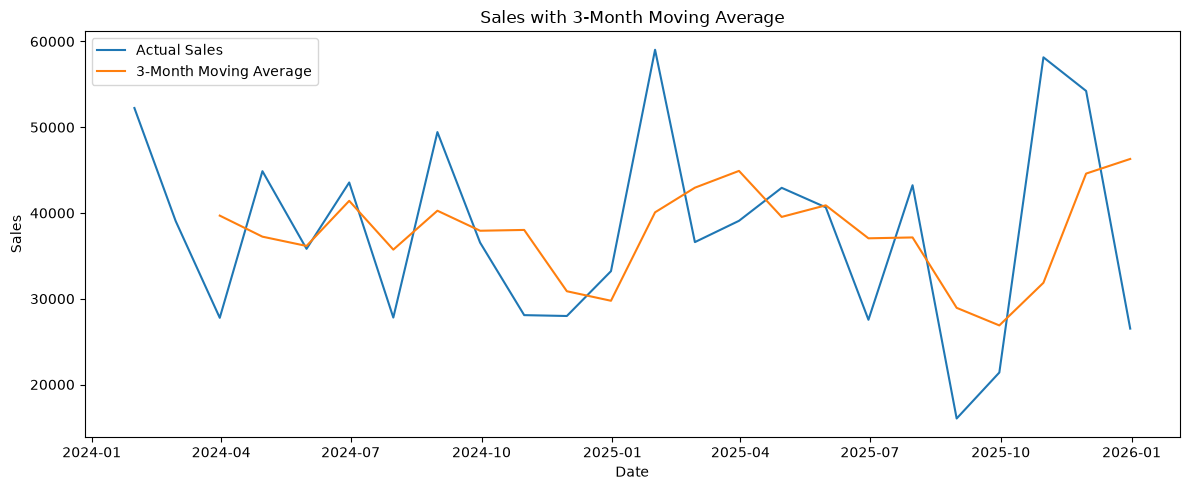

In [27]:
moving_average = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales, label="Actual Sales")
plt.plot(moving_average, label="3-Month Moving Average")

plt.title("Sales with 3-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig("../visualizations/moving_average_forecast.png")

plt.show()

In [28]:
customer_data = df.groupby("Customer_ID").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Discount": "mean",
    "Profit": "sum",
    "Order_ID": "nunique"
}).reset_index()

customer_data.rename(columns={
    "Sales": "Total_Sales",
    "Quantity": "Total_Quantity",
    "Discount": "Average_Discount",
    "Profit": "Total_Profit",
    "Order_ID": "Total_Orders"
}, inplace=True)

customer_data.head()

,Customer_ID,Total_Sales,Total_Quantity,Average_Discount,Total_Profit,Total_Orders
0,CUST-1000,8745.66,24,0.0875,943.08,4
1,CUST-1001,3295.50,11,0.1000,463.97,4
2,CUST-1002,5959.94,16,0.0875,654.93,4
3,CUST-1003,100.82,1,0.1000,20.07,1
4,CUST-1005,19.93,1,0.2000,2.95,1


In [29]:
customer_data = df.groupby("Customer_ID").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Discount": "mean",
    "Profit": "sum",
    "Order_ID": "nunique"
}).reset_index()

customer_data.rename(columns={
    "Sales": "Total_Sales",
    "Quantity": "Total_Quantity",
    "Discount": "Average_Discount",
    "Profit": "Total_Profit",
    "Order_ID": "Total_Orders"
}, inplace=True)

customer_data.head()

,Customer_ID,Total_Sales,Total_Quantity,Average_Discount,Total_Profit,Total_Orders
0,CUST-1000,8745.66,24,0.0875,943.08,4
1,CUST-1001,3295.50,11,0.1000,463.97,4
2,CUST-1002,5959.94,16,0.0875,654.93,4
3,CUST-1003,100.82,1,0.1000,20.07,1
4,CUST-1005,19.93,1,0.2000,2.95,1


In [30]:
clustering_features = [
    "Total_Sales",
    "Total_Quantity",
    "Average_Discount",
    "Total_Profit",
    "Total_Orders"
]

X_cluster = customer_data[clustering_features]

X_cluster.head()

,Total_Sales,Total_Quantity,Average_Discount,Total_Profit,Total_Orders
0,8745.66,24,0.0875,943.08,4
1,3295.50,11,0.1000,463.97,4
2,5959.94,16,0.0875,654.93,4
3,100.82,1,0.1000,20.07,1
4,19.93,1,0.2000,2.95,1


In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print("Features scaled successfully.")

Features scaled successfully.


In [32]:
inertia = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

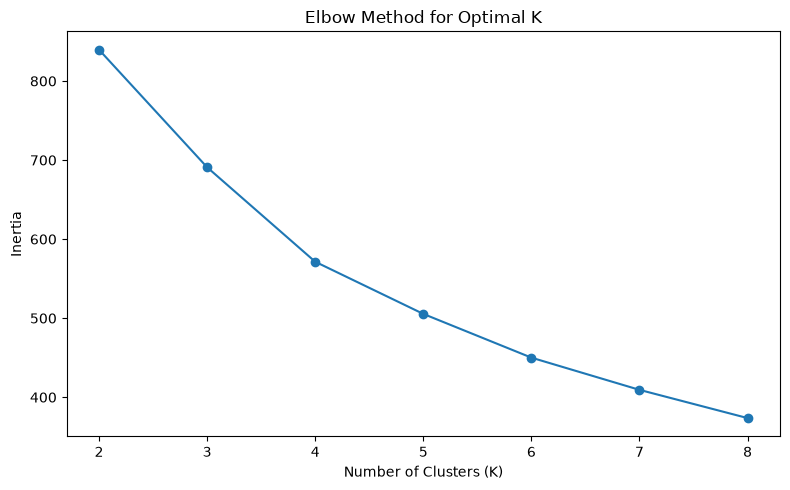

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.tight_layout()

plt.savefig("../visualizations/elbow_method.png")

plt.show()

In [34]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(X_scaled)

customer_data.head()

,Customer_ID,Total_Sales,Total_Quantity,Average_Discount,Total_Profit,Total_Orders,Cluster
0,CUST-1000,8745.66,24,0.0875,943.08,4,2
1,CUST-1001,3295.50,11,0.1000,463.97,4,0
2,CUST-1002,5959.94,16,0.0875,654.93,4,0
3,CUST-1003,100.82,1,0.1000,20.07,1,3
4,CUST-1005,19.93,1,0.2000,2.95,1,3


In [35]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

customer_data["PCA1"] = X_pca[:, 0]
customer_data["PCA2"] = X_pca[:, 1]

print("Explained variance:")
print(pca.explained_variance_ratio_)

Explained variance:
[0.61528393 0.20239283]


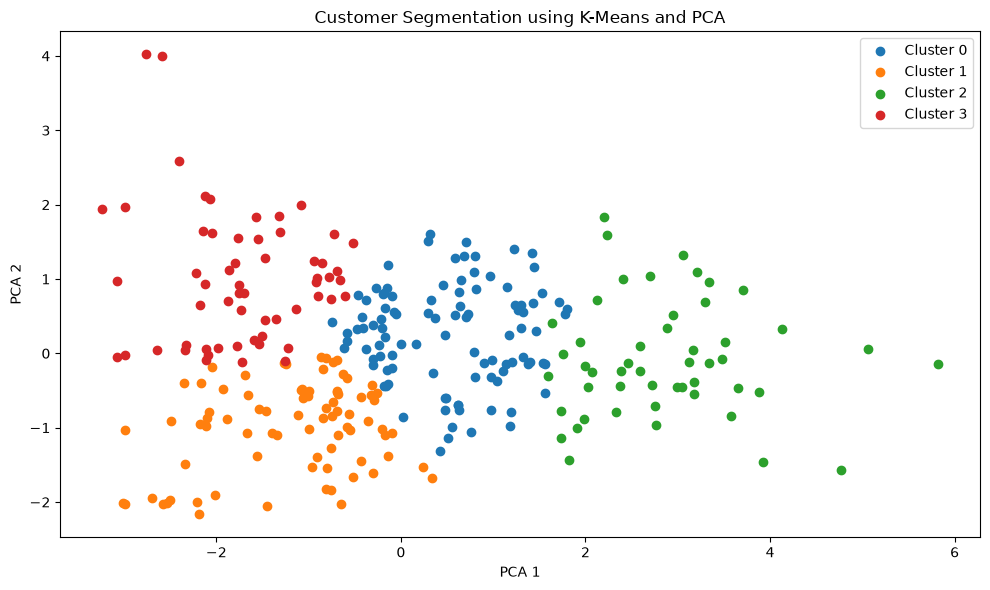

In [36]:
plt.figure(figsize=(10, 6))

for cluster in sorted(customer_data["Cluster"].unique()):
    cluster_data = customer_data[
        customer_data["Cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segmentation using K-Means and PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()

plt.tight_layout()

plt.savefig("../visualizations/customer_clusters.png")

plt.show()

In [37]:
cluster_profile = customer_data.groupby("Cluster")[clustering_features].mean()

cluster_profile

,Total_Sales,Total_Quantity,Average_Discount,Total_Profit,Total_Orders
Cluster,,,,,
0,3586.356683,16.099010,0.100354,422.187426,4.049505
1,1836.771625,8.875000,0.045198,233.131875,2.450000
2,6361.322800,24.080000,0.079702,762.289400,5.480000
3,1459.393534,7.982759,0.146236,154.495517,2.086207


In [38]:
cluster_counts = customer_data["Cluster"].value_counts().sort_index()

print("Customers in each segment:")
print(cluster_counts)

Customers in each segment:
Cluster
0    101
1     80
2     50
3     58
Name: count, dtype: int64


In [39]:
print("CUSTOMER SEGMENT RECOMMENDATIONS")
print("---------------------------------")

for cluster in sorted(customer_data["Cluster"].unique()):
    
    segment = cluster_profile.loc[cluster]
    
    print(f"\nCluster {cluster}")
    print(f"Average Sales: {segment['Total_Sales']:.2f}")
    print(f"Average Orders: {segment['Total_Orders']:.2f}")
    print(f"Average Profit: {segment['Total_Profit']:.2f}")
    print(f"Average Discount: {segment['Average_Discount']:.2f}")
    
    if segment["Total_Sales"] >= cluster_profile["Total_Sales"].median():
        print("Recommendation: Focus on retention, loyalty offers and premium products.")
    else:
        print("Recommendation: Use targeted promotions and campaigns to increase purchases.")

CUSTOMER SEGMENT RECOMMENDATIONS
---------------------------------

Cluster 0
Average Sales: 3586.36
Average Orders: 4.05
Average Profit: 422.19
Average Discount: 0.10
Recommendation: Focus on retention, loyalty offers and premium products.

Cluster 1
Average Sales: 1836.77
Average Orders: 2.45
Average Profit: 233.13
Average Discount: 0.05
Recommendation: Use targeted promotions and campaigns to increase purchases.

Cluster 2
Average Sales: 6361.32
Average Orders: 5.48
Average Profit: 762.29
Average Discount: 0.08
Recommendation: Focus on retention, loyalty offers and premium products.

Cluster 3
Average Sales: 1459.39
Average Orders: 2.09
Average Profit: 154.50
Average Discount: 0.15
Recommendation: Use targeted promotions and campaigns to increase purchases.


PART 5 — BASIC PREDICTIVE MODEL

In [40]:
prediction_data = df[
    ["Quantity", "Discount", "Profit", "Sales"]
].dropna()

prediction_data.head()

,Quantity,Discount,Profit,Sales
0,6,0.15,195.36,1376.680
1,3,0.00,153.36,789.880
2,6,0.05,59.73,332.730
3,1,0.00,14.52,107.800
4,5,0.00,366.03,3074.035


In [41]:
X = prediction_data[
    ["Quantity", "Discount", "Profit"]
]

y = prediction_data["Sales"]

print("Features:")
print(X.columns)

print("\nTarget:")
print("Sales")

Features:
Index(['Quantity', 'Discount', 'Profit'], dtype='object')

Target:
Sales


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


In [43]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [44]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[2212.37046911 1684.13856678  469.40779258  642.36847995  173.33576795
  795.92745141   46.28219189  366.92548366  585.82092788 2626.5414766 ]


In [45]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.769155164495768


In [46]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 319.12243441379064


In [47]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 471.4156079854617


In [48]:
model_results = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

model_results

,Metric,Value
0,R²,0.769155
1,MAE,319.122434
2,RMSE,471.415608


In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

top_3_features = feature_importance.head(3)

top_3_features

,Feature,Coefficient,Absolute_Importance
1,Discount,1597.577442,1597.577442
0,Quantity,40.743303,40.743303
2,Profit,7.093627,7.093627


In [50]:
import joblib

joblib.dump(
    model,
    "../models/linear_regression_sales_model.pkl"
)

print("Prediction model saved successfully.")

Prediction model saved successfully.


In [51]:
print("=" * 60)
print("TASK 4 — ADVANCED ANALYTICS & STATISTICAL MODELING")
print("=" * 60)

print("\n1. DESCRIPTIVE STATISTICS")
print("   Mean")
print("   Median")
print("   Mode")
print("   Standard Deviation")
print("   Skewness")

print("\n2. HYPOTHESIS TESTING")
print("   T-Test")
print("   Chi-Square Test")
print("   95% Confidence Interval")

print("\n3. TIME SERIES ANALYSIS")
print("   Daily Resampling")
print("   Weekly Resampling")
print("   Monthly Resampling")
print("   Trend")
print("   Seasonality")
print("   Residual")
print("   Moving Average Forecast")

print("\n4. CUSTOMER SEGMENTATION")
print("   StandardScaler")
print("   Elbow Method")
print("   K-Means Clustering")
print("   PCA 2D")
print("   Segment Profiling")
print("   Recommendations")

print("\n5. PREDICTIVE MODEL")
print("   Target: Sales")
print("   Train/Test Split: 80/20")
print("   Linear Regression")
print(f"   R²: {r2:.4f}")
print(f"   MAE: {mae:.4f}")
print(f"   RMSE: {rmse:.4f}")
print("   Top 3 Important Features")

print("\nTASK 4 ANALYSIS COMPLETED")

TASK 4 — ADVANCED ANALYTICS & STATISTICAL MODELING

1. DESCRIPTIVE STATISTICS
   Mean
   Median
   Mode
   Standard Deviation
   Skewness

2. HYPOTHESIS TESTING
   T-Test
   Chi-Square Test
   95% Confidence Interval

3. TIME SERIES ANALYSIS
   Daily Resampling
   Weekly Resampling
   Monthly Resampling
   Trend
   Seasonality
   Residual
   Moving Average Forecast

4. CUSTOMER SEGMENTATION
   StandardScaler
   Elbow Method
   K-Means Clustering
   PCA 2D
   Segment Profiling
   Recommendations

5. PREDICTIVE MODEL
   Target: Sales
   Train/Test Split: 80/20
   Linear Regression
   R²: 0.7692
   MAE: 319.1224
   RMSE: 471.4156
   Top 3 Important Features

TASK 4 ANALYSIS COMPLETED
